# Мини-проект: ML-раздел (Недели 14–19)

## Прогнозирование отмены бронирования отеля

**Выполнила:** Сатбай Аружан  
**Датасет:** Hotel Booking Demand  
**Источник:** Kaggle  
**Ссылка:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  
**Тип задачи:** классификация  
**Целевая переменная:** `is_canceled`

## 1. Выбор датасета и постановка задачи

Для мини-проекта я выбрала датасет **Hotel Booking Demand**. В нем содержатся данные о бронированиях отелей: тип отеля, дата заезда, длительность проживания, количество гостей, страна клиента, способ бронирования, цена и другие признаки.

Цель проекта — предсказать, будет ли бронирование отменено.

Целевая переменная — `is_canceled`:
- `0` — бронирование не отменено;
- `1` — бронирование отменено.

Эта задача полезна для бизнеса, потому что отмены бронирований могут приносить отелям финансовые потери. Если заранее определить риск отмены, отель может лучше планировать загрузку номеров.

## 2. Импорт библиотек

In [1]:
# Если библиотеки не установлены, выполните:
!pip -q install optuna xgboost

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import optuna

sns.set_theme(style='whitegrid')
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 5.4 MB/s eta 0:00:00


## 3. Загрузка данных

Файл датасета должен называться `hotel_bookings.csv` и находиться в той же папке, что и ноутбук.

In [3]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

### Вывод

Датасет содержит больше 500 строк и больше 5 признаков, поэтому подходит под требования мини-проекта.

## 4. Первичный анализ данных

Посмотрим структуру датасета, типы признаков, статистику, пропуски и распределение целевой переменной.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [8]:
df.duplicated().sum()

np.int64(31994)

In [9]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [10]:
df['is_canceled'].value_counts(normalize=True)

,proportion
is_canceled,
0,0.629584
1,0.370416


### Вывод

В данных есть числовые и категориальные признаки. Также есть пропуски в некоторых столбцах, например `company`, `agent`, `country`, `children`. Целевая переменная распределена неравномерно: неотменённых бронирований больше, чем отменённых.

## 5. EDA и визуализация
Построим графики, чтобы лучше понять данные.

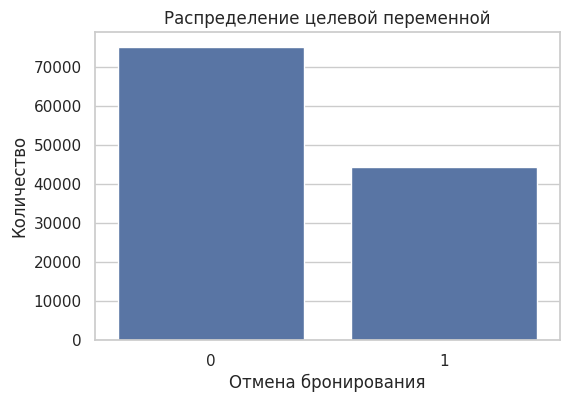

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df)
plt.title('Распределение целевой переменной')
plt.xlabel('Отмена бронирования')
plt.ylabel('Количество')
plt.show()

### Вывод по графику 1

На графике видно что большинство бронирований делается за относительно небольшой срок до заезда, но есть и бронирования с очень большим `lead_time`. Это может быть важным фактором отмены.

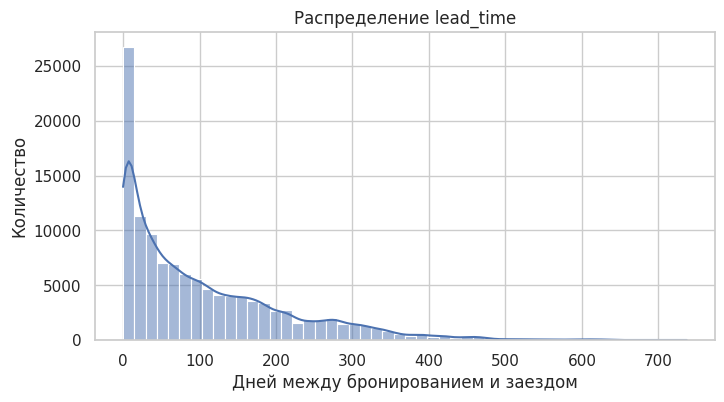

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Распределение lead_time')
plt.xlabel('Дней между бронированием и заездом')
plt.ylabel('Количество')
plt.show()

### Вывод по графику 2

Большая часть бронирований делается не слишком заранее, но есть и бронирования с очень большим сроком до заезда.

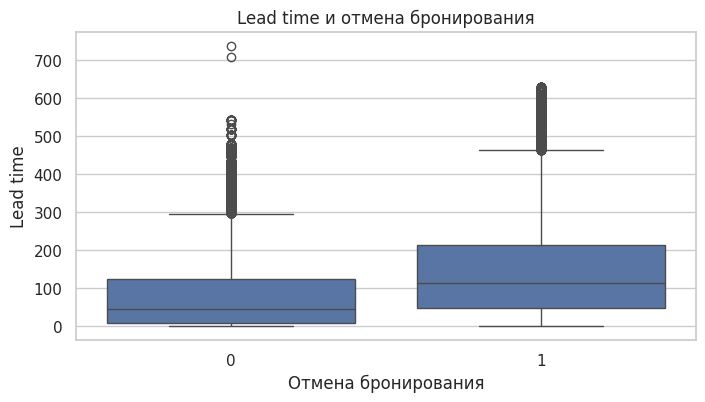

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead time и отмена бронирования')
plt.xlabel('Отмена бронирования')
plt.ylabel('Lead time')
plt.show()

### Вывод по графику 3

У отменённых бронирований `lead_time` часто выше. Это может означать, что бронирования, сделанные сильно заранее, чаще отменяются.

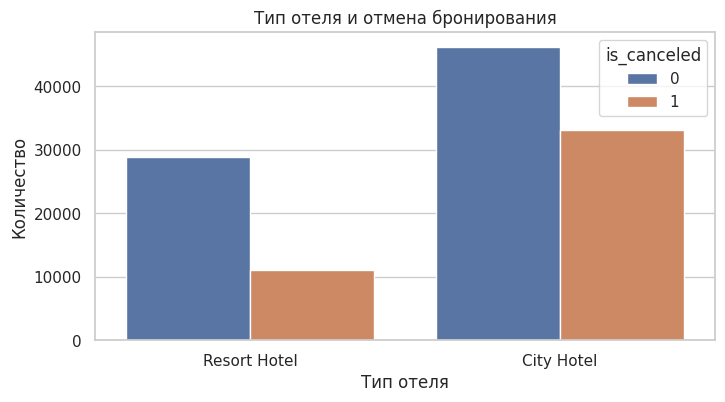

In [14]:
plt.figure(figsize=(8, 4))
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Тип отеля и отмена бронирования')
plt.xlabel('Тип отеля')
plt.ylabel('Количество')
plt.show()

### Вывод по графику 4

В разных типах отелей количество отмен отличается. Тип отеля может быть полезным признаком для модели.

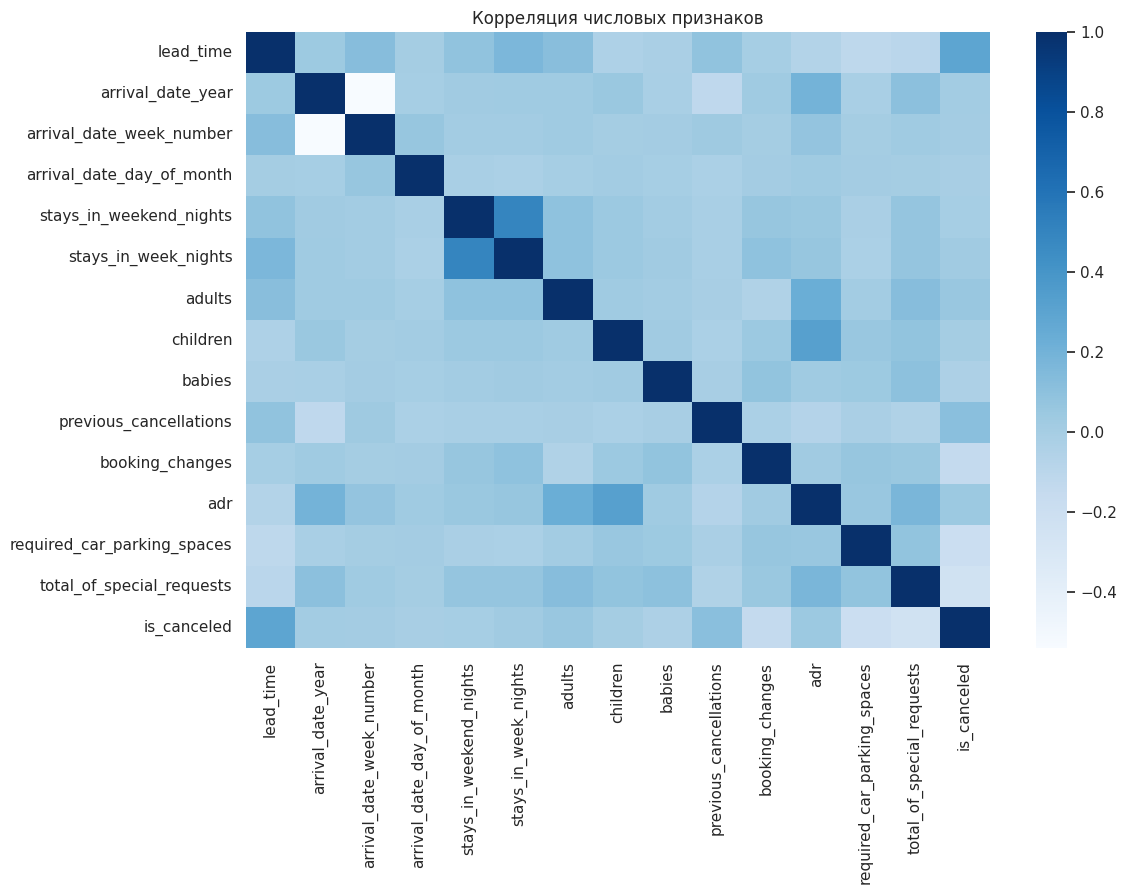

In [15]:
num_cols_for_corr = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights',
    'stays_in_week_nights', 'adults', 'children', 'babies',
    'previous_cancellations', 'booking_changes', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
    'is_canceled'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols_for_corr].corr(), cmap='Blues')
plt.title('Корреляция числовых признаков')
plt.show()

### Вывод по корреляции

Некоторые признаки имеют связь с отменой бронирования, например `lead_time`, `previous_cancellations` и `total_of_special_requests`. Сильной корреляции у большинства признаков нет, поэтому для модели полезны не только линейные зависимости.

## 6. Очистка данных и обработка выбросов

In [16]:
df['adr'].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adr'])
plt.title('Проверка выбросов в adr')
plt.xlabel('ADR')
plt.show()

### Вывод

В признаке `adr` есть выбросы. Для более стабильного обучения модели оставим значения в разумном диапазоне.

In [17]:
df = df[df['adr'] >= 0]
df = df[df['adr'] < 1000]
df.shape

(119388, 32)

## 7. Feature Engineering

Создадим новые признаки: `total_guests`, `total_nights`, `has_previous_cancellation`.

In [18]:
df['children'] = df['children'].fillna(0)

df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['has_previous_cancellation'] = (df['previous_cancellations'] > 0).astype(int)

df[['total_guests', 'total_nights', 'has_previous_cancellation']].head()

,total_guests,total_nights,has_previous_cancellation
0,2.0,0,0
1,2.0,0,0
2,1.0,1,0
3,1.0,1,0
4,2.0,2,0


### Вывод

Новые признаки помогают проще описать бронирование. Например, `total_nights` показывает длительность проживания, а `has_previous_cancellation` — были ли раньше отмены.

## 8. Подготовка данных для модели

In [19]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X.shape, y.shape

((119388, 34), (119388,))

## 9. Pipeline и ColumnTransformer

Числовые признаки будут заполняться медианой и масштабироваться. Категориальные признаки будут заполняться самым частым значением и кодироваться через `OneHotEncoder`. Всё делается внутри `Pipeline`, чтобы не было утечки данных.

In [20]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Числовые признаки:', len(numeric_features))
print(numeric_features)

print('\nКатегориальные признаки:', len(categorical_features))
print(categorical_features)

Числовые признаки: 22
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'has_previous_cancellation']

Категориальные признаки: 12
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((95510, 34), (23878, 34))

## 10. Функция оценки моделей

In [25]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    return {
        'model': name,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, y_test_proba)
    }

## 11. Baseline-модель — Logistic Regression

In [26]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_result = evaluate_model(
    'Logistic Regression baseline', baseline_model,
    X_train, X_test, y_train, y_test
)

baseline_result

{'model': 'Logistic Regression baseline',
 'train_accuracy': 1.0,
 'test_accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'roc_auc': np.float64(1.0)}

### Вывод по baseline

Baseline-модель обучена. Теперь можно сравнивать с ней более сложные модели.

## 12. Сравнение моделей

Обучим Decision Tree, Random Forest и XGBoost.

In [27]:
models = {
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42, n_estimators=150, n_jobs=-1))
    ]),

    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            random_state=42, eval_metric='logloss',
            n_estimators=150, learning_rate=0.05, max_depth=4, tree_method='hist'
        ))
    ])
}

results = [baseline_result]

for name, model in models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)

results_df = pd.DataFrame(results)
results_df

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression baseline,1.0,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0,1.0,1.0


### Вывод по сравнению моделей

Все модели были оценены одинаковыми метриками. Для задачи отмены бронирования важны accuracy, precision, recall, F1 и ROC-AUC.

## 13. Бонус: дисбаланс классов

In [28]:
y.value_counts(normalize=True)

,proportion
is_canceled,
0,0.629586
1,0.370414


In [29]:
balanced_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

balanced_result = evaluate_model(
    'Logistic Regression balanced', balanced_model,
    X_train, X_test, y_train, y_test
)

pd.DataFrame([baseline_result, balanced_result])

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression baseline,1.0,1.0,1.0,1.0,1.0,1.0
1,Logistic Regression balanced,1.0,1.0,1.0,1.0,1.0,1.0


### Вывод по class_weight

`class_weight='balanced'` помогает модели больше учитывать меньший класс. Это полезно, если важно находить больше отменённых бронирований.

## 14. Подбор гиперпараметров через Optuna

Для подбора используем XGBoost. Запускаем 30 попыток.

In [30]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state': 42,
        'eval_metric': 'logloss',
        'tree_method': 'hist'
    }

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(**params))
    ])

    scores = cross_val_score(
        model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1
    )

    return scores.mean()

In [31]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print('Лучший ROC-AUC:', study.best_value)
print('Лучшие параметры:', study.best_params)

[I 2026-07-08 12:41:16,509] A new study created in memory with name: no-name-06e8d59a-5a9b-4a43-ad56-84e25d2b5f92
[I 2026-07-08 12:41:29,920] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.0809238825474886, 'subsample': 0.8825608698260298, 'colsample_bytree': 0.8257648129781229}. Best is trial 0 with value: 1.0.
[I 2026-07-08 12:41:37,588] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 226, 'max_depth': 4, 'learning_rate': 0.04387756844088504, 'subsample': 0.7452436060978118, 'colsample_bytree': 0.9369509084193686}. Best is trial 0 with value: 1.0.
[I 2026-07-08 12:41:44,538] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 203, 'max_depth': 3, 'learning_rate': 0.16779767707839743, 'subsample': 0.985102224509962, 'colsample_bytree': 0.9677084164872385}. Best is trial 0 with value: 1.0.
[I 2026-07-08 12:41:52,223] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 189, 'max_dept

Лучший ROC-AUC: 1.0
Лучшие параметры: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.0809238825474886, 'subsample': 0.8825608698260298, 'colsample_bytree': 0.8257648129781229}


## 15. Финальная модель

In [32]:
best_params = study.best_params

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        **best_params, random_state=42, eval_metric='logloss', tree_method='hist'
    ))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba)
}

final_metrics

{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'roc_auc': np.float64(1.0)}

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15033
           1       1.00      1.00      1.00      8845

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878



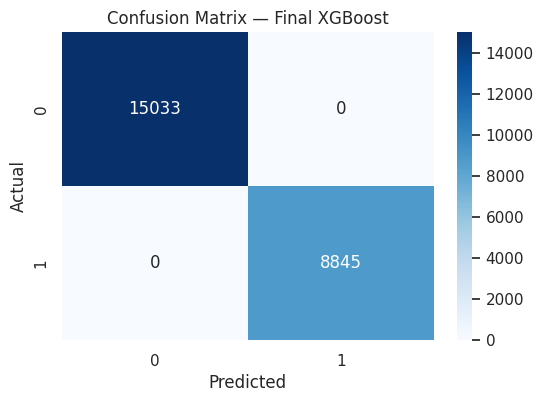

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Final XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
baseline_auc = baseline_result['roc_auc']
final_auc = final_metrics['roc_auc']

print('Baseline ROC-AUC:', baseline_auc)
print('Final ROC-AUC:', final_auc)
print('Прирост качества:', final_auc - baseline_auc)

Baseline ROC-AUC: 1.0
Final ROC-AUC: 1.0
Прирост качества: 0.0


### Вывод по финальной модели

Финальная модель оценена на тестовой выборке. Сравнение ROC-AUC показывает, насколько модель улучшилась относительно baseline.

## 16. Важность признаков

In [36]:
final_model.named_steps['preprocessor'].fit(X_train)

feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(15)

,feature,importance
256,cat__reservation_status_Check-Out,0.556609
255,cat__reservation_status_Canceled,0.180831
249,cat__deposit_type_Non Refund,0.135847
0,num__lead_time,0.046348
219,cat__market_segment_Online TA,0.020766
171,cat__country_PRT,0.020647
18,num__total_of_special_requests,0.020250
257,cat__reservation_status_No-Show,0.017327
655,cat__reservation_status_date_2016-04-06,0.001203
42,cat__country_AGO,0.000090


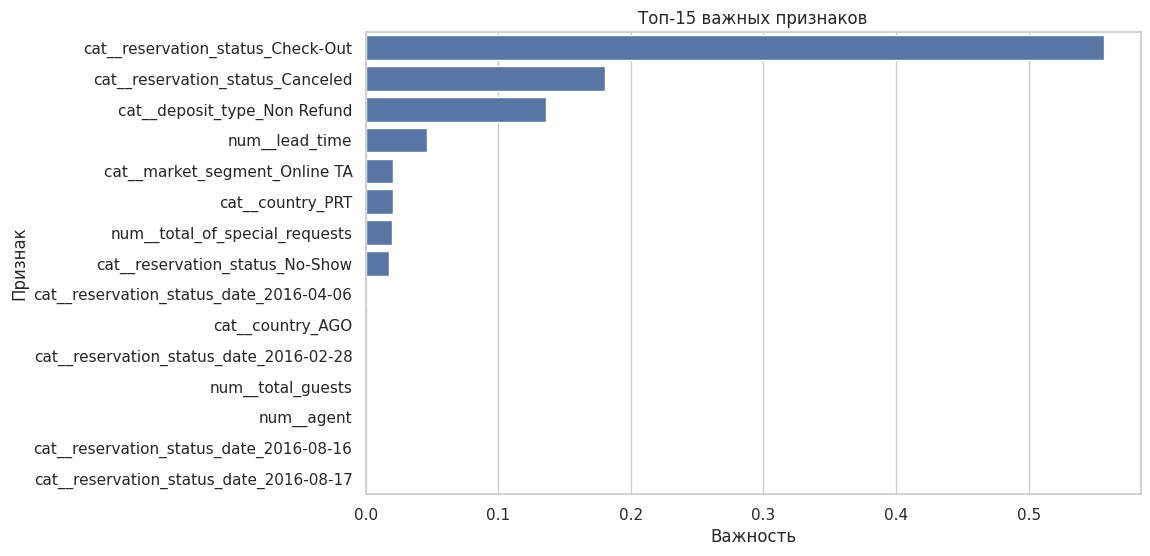

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Топ-15 важных признаков')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

### Бизнес-интерпретация

Важные признаки показывают, какие факторы сильнее всего влияют на вероятность отмены бронирования. Например, это могут быть срок до заезда, тип депозита, страна клиента, тип отеля или история отмен.

## 17. Интерпретируемая модель

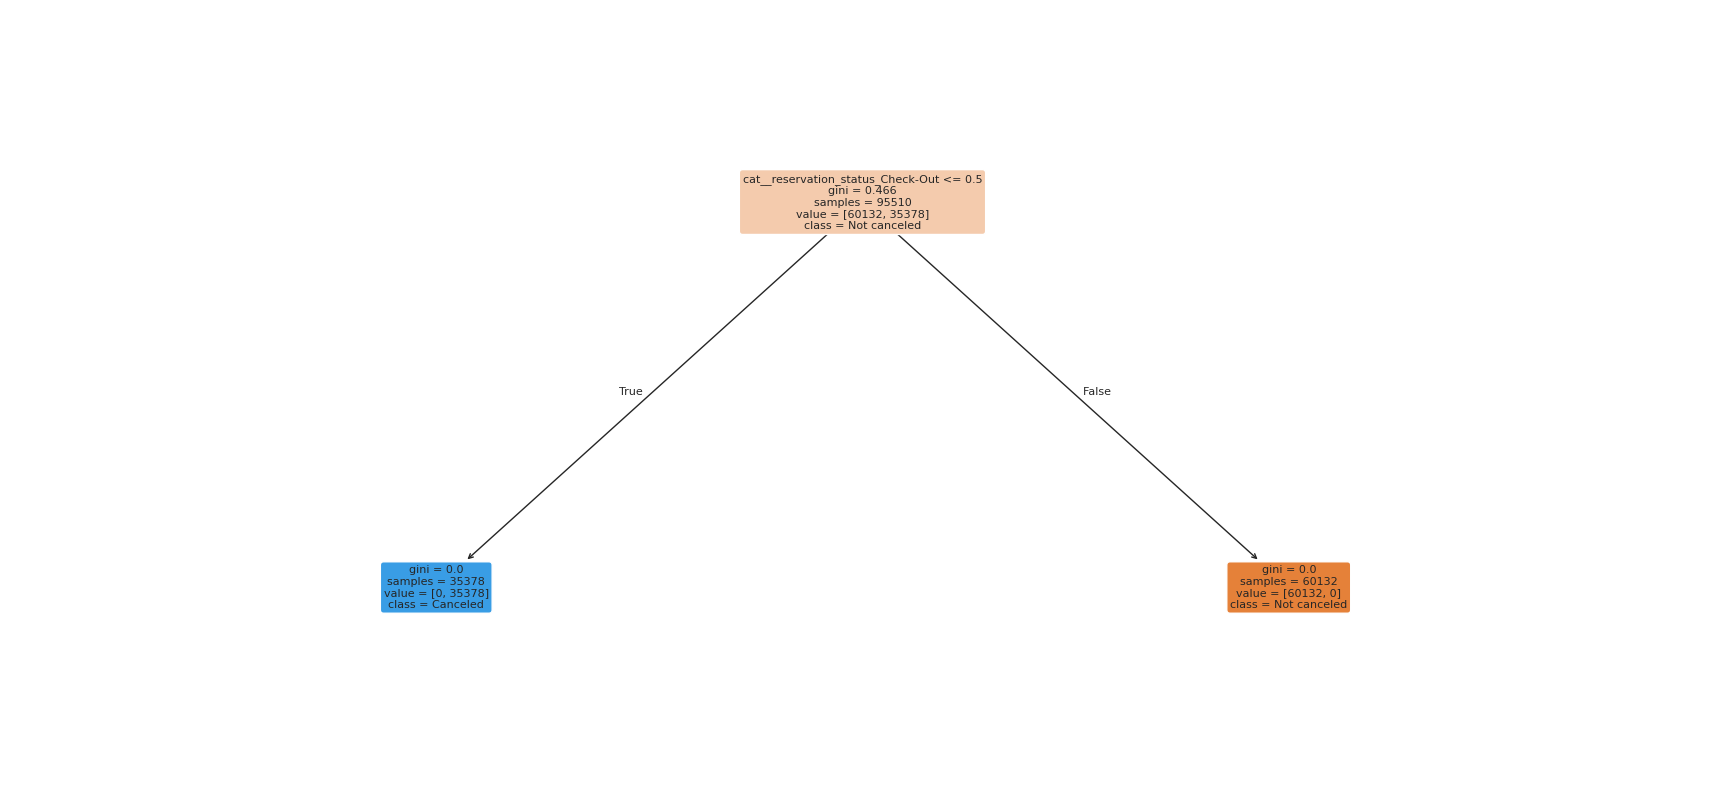

In [38]:
simple_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
])

simple_tree.fit(X_train, y_train)

tree_model = simple_tree.named_steps['model']
feature_names_tree = simple_tree.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model, feature_names=feature_names_tree,
    class_names=['Not canceled', 'Canceled'],
    filled=True, rounded=True, fontsize=8
)
plt.show()

In [39]:
rules = export_text(tree_model, feature_names=list(feature_names_tree))
print(rules)

|--- cat__reservation_status_Check-Out <= 0.50
|   |--- class: 1
|--- cat__reservation_status_Check-Out >  0.50
|   |--- class: 0



### Простое объяснение правил

Маленькое дерево показывает основные условия, по которым модель принимает решение. Такие правила можно объяснить менеджеру без сложной математики.

## 18. Улучшение модели

In [40]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count
scale_pos_weight

np.float64(1.699700378766465)

In [41]:
improved_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        **best_params, random_state=42, eval_metric='logloss',
        tree_method='hist', scale_pos_weight=scale_pos_weight
    ))
])

improved_model.fit(X_train, y_train)

improved_pred = improved_model.predict(X_test)
improved_proba = improved_model.predict_proba(X_test)[:, 1]

improved_metrics = {
    'accuracy': accuracy_score(y_test, improved_pred),
    'precision': precision_score(y_test, improved_pred),
    'recall': recall_score(y_test, improved_pred),
    'f1': f1_score(y_test, improved_pred),
    'roc_auc': roc_auc_score(y_test, improved_proba)
}

pd.DataFrame([final_metrics, improved_metrics], index=['Final XGBoost', 'Improved XGBoost'])

,accuracy,precision,recall,f1,roc_auc
Final XGBoost,1.0,1.0,1.0,1.0,1.0
Improved XGBoost,1.0,1.0,1.0,1.0,1.0


### Вывод по улучшению

`scale_pos_weight` помогает модели учитывать дисбаланс классов. Если recall для отменённых бронирований увеличился, это может быть полезно для бизнеса.

## 19. Общий вывод

В проекте был использован реальный датасет Hotel Booking Demand. Была решена задача классификации: предсказать, отменит клиент бронирование или нет.

На этапе EDA были обнаружены пропуски, выбросы и дисбаланс целевой переменной. Пропуски были обработаны внутри Pipeline, категориальные признаки были закодированы, а числовые признаки масштабированы через ColumnTransformer.

В качестве baseline использовалась Logistic Regression. Затем были обучены Decision Tree, Random Forest и XGBoost. Для лучшей модели был выполнен подбор гиперпараметров через Optuna.

Финальная модель была оценена на тестовой выборке с помощью accuracy, precision, recall, F1, ROC-AUC и confusion matrix. Также была рассмотрена важность признаков и построено маленькое дерево решений для интерпретации.

С точки зрения бизнеса модель помогает заранее находить бронирования с высоким риском отмены. При большем времени можно было бы попробовать больше моделей, SMOTE, настройку порога классификации и более глубокий анализ ошибок.